# Customer Satisfaction & Reviews

## BUSINESS CASE

### PERTANYAN BUSINESS

1. Bagaimana distribusi review score (1–5) secara keseluruhan?
2. Apakah jumlah item yang dibeli dalam satu order berkaitan dengan rata-rata review score?
3. Apakah keterlambatan pengiriman berkorelasi dengan review score rendah?

 **Catatan:**

Business question pada Bagian 6 disesuaikan setelah dilakukan Data Understanding terhadap hubungan antara tabel `order_reviews`, `orders`, `order_items`, dan `products`. Pertanyaan awal mengenai perbandingan review score berdasarkan kategori produk tidak dilanjutkan karena `order_reviews` tidak memiliki `product_id` atau `order_item_id`, sehingga review tidak dapat dikaitkan secara langsung dengan produk tertentu tanpa menimbulkan hubungan many-to-many dalam satu order. Oleh karena itu, pertanyaan tersebut diganti dengan analisis hubungan antara jumlah item dalam order dan rata-rata review score.


### SCOPE ANALYSIS

Analisis mencakup seluruh data review yang tersedia. Untuk analisis delivery, hanya order dengan order_status = 'delivered' yang digunakan._

## IMPORT LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## GATHERING DATA

In [2]:
order = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/orders_dataset.csv')
order_items = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_items_dataset.csv')
order_review = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_reviews_dataset.csv')

## UNDERSTANDING DATA

In [3]:
order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
order_review.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


### GRAIN

1. tabel order : 1 row merepresntasikan 1 order
2. tabel order_review : 1 row merepresntasikan 1 review dalam sebuah order
3. tabel order_items : 1 row mempresentasikan item dalam sebuah order

### KEY COLUMN

1. **Tabel `order_review`**:
   - `order_id` → identifier untuk setiap order, digunakan untuk menghubungkan `order` dan `order_review`
   - `review_score` → score review untuk tiap order

3.  **Tabel `order`**:
    - `order_id` → identifier untuk setiap order
    - `order_status` → status order
    - `order_purchase_timestamp` → waktu saat customer melakukan order
    - `order_delivered_customer_date` → waktu saat pelanggan menerima barang
    - `order_estimated_delivery_date` → estimasi waktu saat pelanggan menerima barang
3. **Tabel `order_items`**:
   - `order_id` → identifier order, digunakan untuk menghubungkan `order_items` dengan `orders`
   - `product_id` → identifier product, digunakan untuk menghubungkan `order_items` dengan `products`

### RELATIONSHIP TABLE 

- Tabel `order_review` dan `order` terhubung melalui `order_id`.
- Tabel `order` dan `order_items` terhubung melalui `order_id`.

- `order` memiliki hubungan **one-to-many** (1:M) dengan `order_review`, karena satu order dapat memiliki lebih dari satu record review. .     
- `order` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu order dapat memiliki beberapa item.

## DATA QUALITY

In [6]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


1. Untuk kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` masih berbentuk object belum datetime

In [7]:
order.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [8]:
print('Checking null value')
order.isna().sum()

Checking null value


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

1.  Untuk kolom ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date``` terdapat missing value

In [9]:
print('Checking duplicated value')
order.duplicated().sum()

Checking duplicated value


0

In [10]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [11]:
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [12]:
print('Checking null value')
order_items.isna().sum()

Checking null value


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [13]:
print('Checking duplicated value')
order_items.duplicated().sum()

Checking duplicated value


0

In [14]:
order_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


1. Untuk kolom ```review_creation_date```,```review_answer_timestamp``` masih berbentuk object belum datetime

In [15]:
order_review.describe(include='all')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,7b606b0d57b078384f0b58eac1d41d78,c88b1d1b157a9999ce368f218a407141,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [16]:
print('Checking null value')
order_review.isna().sum()

Checking null value


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

1.  Untuk kolom ```review_comment_message```, ```review_comment_title``` terdapat missing value

In [17]:
print('Checking duplicated value')
order_review.duplicated().sum()

Checking duplicated value


0

In [18]:
print('Checking duplicated value order_id')
order_review['order_id'].duplicated().sum()

Checking duplicated value order_id


551

Pada tabel order_reviews ditemukan beberapa order_id yang memiliki lebih dari satu review record. Kondisi ini perlu diperhatikan karena order_id tidak selalu merepresentasikan satu review record.

### DATA QUALITY

## DATA PREPARATION

## EXPLORATORY DATA ANALYSIS

### 1. Bagaimana distribusi review score (1–5) secara keseluruhan?

In [19]:
distribution_review = order_review[['order_id','review_score']]

In [20]:
distribtuion_score_review = distribution_review.groupby('review_score')['order_id'].count().reset_index()

In [21]:
distribtuion_score_review

,review_score,order_id
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


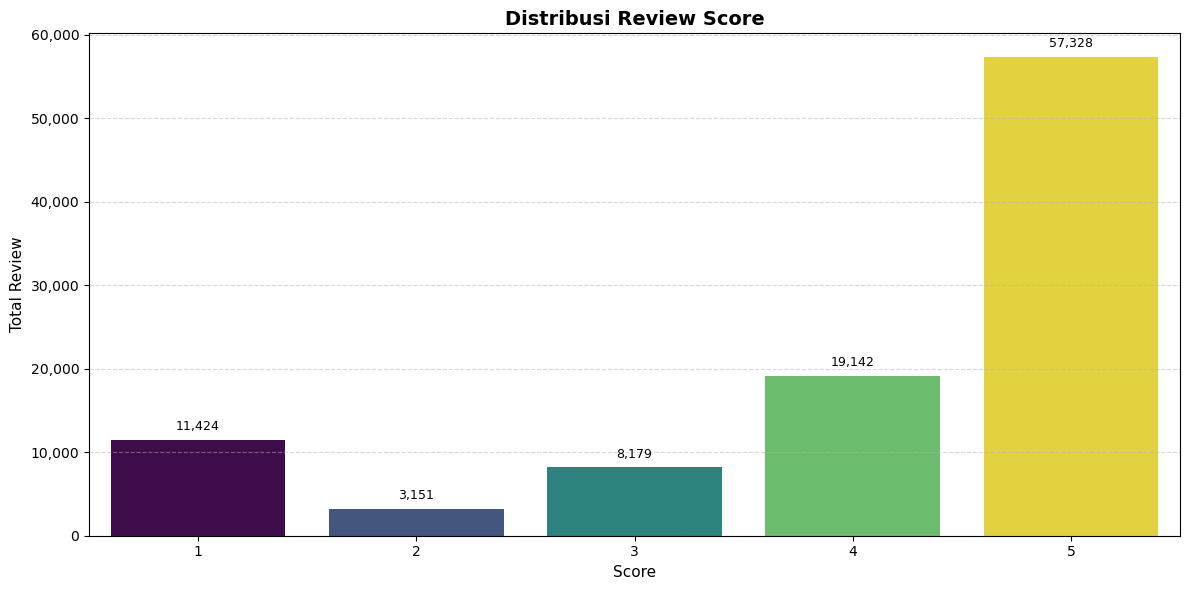

In [22]:
# 1. Mendefinisikan urutan score
score = [1, 2, 3, 4, 5]

plt.figure(figsize=(12, 6))

# 2. Membuat Vertical Bar Plot dengan Gradient Warna (Palette)
ax = sns.barplot(
    data=distribtuion_score_review,
    x='review_score',              
    y='order_id',   
    order=score,
    palette='viridis',        # Menggunakan palette gradient (contoh: biru dari gelap ke terang)
    hue='review_score',       # Ditambahkan agar palette berfungsi optimal di Seaborn terbaru
    legend=False              # Menyembunyikan legend karena hue hanya digunakan untuk warna
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}',      
        padding=5,          
        fontsize=9
    )

# 4. Mengatasi format angka pada sumbu Y
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 5. Judul dan Label Sumbu
plt.title('Distribusi Review Score', fontsize=14, fontweight='bold')
plt.xlabel('Score', fontsize=11)
plt.ylabel('Total Review', fontsize=11)

# 6. Grid disesuaikan menjadi horizontal (sumbu Y)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout() 
plt.show()

#### KEY INSIGHT

1. Review score 5 menjadi skor yang paling dominan dengan total **57.328 review**, menunjukkan sebagian besar review berada pada tingkat kepuasan tertinggi.
2. Review score 4 menjadi skor terbanyak kedua dengan total **19.142 review**, sehingga review positif (score 4–5) mendominasi distribusi keseluruhan.


### 2. Apakah jumlah item yang dibeli dalam satu order berkaitan dengan rata-rata review score? 

In [23]:
##AVERAGE REVIEW SCORE PER ORDER
avg_score = order_review[['order_id','review_score']]

In [24]:
avg_review_score = avg_score.groupby('order_id')['review_score'].mean().reset_index()
avg_review_score

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0
...,...,...
98668,fffc94f6ce00a00581880bf54a75a037,5.0
98669,fffcd46ef2263f404302a634eb57f7eb,5.0
98670,fffce4705a9662cd70adb13d4a31832d,5.0
98671,fffe18544ffabc95dfada21779c9644f,5.0


In [25]:
## TOTAL ITEM PER ORDER
total_item = order_items[['order_id','product_id']]

In [26]:
count_total_item = order_items.groupby('order_id')['product_id'].count().reset_index()
count_total_item

,order_id,product_id
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,1
98662,fffcd46ef2263f404302a634eb57f7eb,1
98663,fffce4705a9662cd70adb13d4a31832d,1
98664,fffe18544ffabc95dfada21779c9644f,1


In [27]:
## JOIN TABLE
total_item_corr_avg_score = pd.merge(
    left = avg_review_score,
    right = count_total_item,
    how = 'inner',
    on = 'order_id'
)

In [28]:
total_item_corr_avg_score = total_item_corr_avg_score[['product_id','review_score','order_id']]
total_item_corr_avg_score

,product_id,review_score,order_id
0,1,5.0,00010242fe8c5a6d1ba2dd792cb16214
1,1,4.0,00018f77f2f0320c557190d7a144bdd3
2,1,5.0,000229ec398224ef6ca0657da4fc703e
3,1,4.0,00024acbcdf0a6daa1e931b038114c75
4,1,5.0,00042b26cf59d7ce69dfabb4e55b4fd9
...,...,...,...
97912,1,5.0,fffc94f6ce00a00581880bf54a75a037
97913,1,5.0,fffcd46ef2263f404302a634eb57f7eb
97914,1,5.0,fffce4705a9662cd70adb13d4a31832d
97915,1,5.0,fffe18544ffabc95dfada21779c9644f


In [29]:
total_item_avg_score = total_item_corr_avg_score.groupby('product_id').agg({
    'order_id' : 'count',
    'review_score' : 'mean'
}).reset_index()
total_item_avg_score

,product_id,order_id,review_score
0,1,88227,4.160395
1,2,7440,3.653898
2,3,1300,3.507308
3,4,497,3.341046
4,5,204,3.372549
5,6,192,3.315104
6,7,22,2.909091
7,8,8,4.000000
8,9,3,3.000000
9,10,8,2.250000


In [30]:
total_item_avg_score.corr()

,product_id,order_id,review_score
product_id,1.000000,-0.40539,-0.633206
order_id,-0.405390,1.00000,0.294900
review_score,-0.633206,0.29490,1.000000


In [31]:
total_item_avg_score['item_group'] = np.where(
    total_item_avg_score['product_id'] >= 7,
    '7+',
    total_item_avg_score['product_id'].astype(str)
)
total_item_avg_score['weighted_score'] = (
    total_item_avg_score['review_score'] *
    total_item_avg_score['order_id']
)

total_item_avg_score = (
    total_item_avg_score
    .groupby('item_group')
    .agg(
        total_order=('order_id', 'sum'),
        total_weighted_score=('weighted_score', 'sum')
    )
    .reset_index()
)

total_item_avg_score['review_score'] = (
    total_item_avg_score['total_weighted_score'] /
    total_item_avg_score['total_order']
)

total_item_avg_score = total_item_avg_score[
    ['item_group', 'total_order', 'review_score']
]

In [32]:
total_item_avg_score

,item_group,total_order,review_score
0,1,88227,4.160395
1,2,7440,3.653898
2,3,1300,3.507308
3,4,497,3.341046
4,5,204,3.372549
5,6,192,3.315104
6,7+,57,2.912281


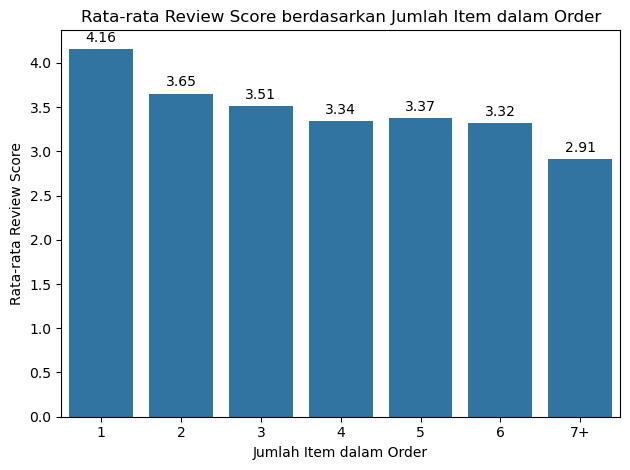

In [33]:
ax = sns.barplot(
    data=total_item_avg_score,
    x='item_group',
    y='review_score'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

ax.set_xlabel('Jumlah Item dalam Order')
ax.set_ylabel('Rata-rata Review Score')
ax.set_title('Rata-rata Review Score berdasarkan Jumlah Item dalam Order')

plt.tight_layout()
plt.show()

#### KEY INSIGHT

1. Order dengan 1 item memiliki rata-rata review score tertinggi, yaitu 4,16.
2. Rata-rata review score menurun dari 4,16 pada order 1 item menjadi sekitar 3,32 pada order 6 item.
3. Kelompok 7+ item memiliki rata-rata review score 2,63, tetapi hanya terdiri dari 57 order, sehingga perlu diinterpretasikan dengan hati-hati karena jumlah observasinya jauh lebih kecil.

### 3.Apakah keterlambatan pengiriman berkorelasi dengan review score rendah?

In [34]:
##FILTER ON TABLE ORDER WHERE COLUMN ORDER_STATUS = DELIVERED
order_clean = order = order[order['order_status'] == 'delivered']

In [35]:
order_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96478 non-null  object
 1   customer_id                    96478 non-null  object
 2   order_status                   96478 non-null  object
 3   order_purchase_timestamp       96478 non-null  object
 4   order_approved_at              96464 non-null  object
 5   order_delivered_carrier_date   96476 non-null  object
 6   order_delivered_customer_date  96470 non-null  object
 7   order_estimated_delivery_date  96478 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [36]:
order_clean = order_clean[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']]

In [37]:
## MELAKUKAN CHECK APAKAH TERADAPAT NILAI NULL 
order_clean.isna().sum()

order_id                         0
order_purchase_timestamp         0
order_delivered_customer_date    8
order_estimated_delivery_date    0
dtype: int64

**DATA QUALITY NOTE**

Untuk analisis apakah keterlambatan pengiriman berkorelasi dengan review score rendah kolom yang digunakan adalah  `order_id`,`order_purchase_timestamp` , `order_estimated_delivery_date`, dan `order_estimated_delivery_date`.
Setelah melakukan filter order_status = delivered, ditemukan missing value pada kolom `order_estimated_delivery_date`. yang memiliki missing value sebanyak **8 order**.

Karena `order_delivered_customer_date` digunakan untuk menentukan waktu pengiriman aktual dan membandingkannya dengan kolom `order_estimated_delivery_date` untuk menentukan apakah order  tersebut termasuk **late atau on time**, nilai yang hilang tidak dapat diimputasi secara valid, oleh karena itu 8 order tersebut dikeluarkan dari analisis Q3.

In [38]:
## MELAKUKAN PENGHAPUSAN BARIS YANG MEMILIKI NILAI NULL PADA KOLOM `order_delivered_customer_date`
order_clean = order_clean.dropna()

In [39]:
order_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96470 entries, 0 to 99440
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96470 non-null  object
 1   order_purchase_timestamp       96470 non-null  object
 2   order_delivered_customer_date  96470 non-null  object
 3   order_estimated_delivery_date  96470 non-null  object
dtypes: object(4)
memory usage: 3.7+ MB


In [40]:
order_clean.isna().sum()

order_id                         0
order_purchase_timestamp         0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [41]:
## MENGUBAH KOLOM `order_id`,`order_purchase_timestamp` , `order_estimated_delivery_date`, dan `order_estimated_delivery_date` menjadi datetime
order_clean['order_purchase_timestamp'] = pd.to_datetime(order_clean['order_purchase_timestamp'])
order_clean['order_delivered_customer_date'] = pd.to_datetime(order_clean['order_delivered_customer_date'])
order_clean['order_estimated_delivery_date'] = pd.to_datetime(order_clean['order_estimated_delivery_date'])

In [42]:
mean_score = order_review[['order_id','review_score']]

In [43]:
mean_score = mean_score.groupby('order_id')['review_score'].mean().reset_index()

In [44]:
## JOIN TABLE
order_review_score = pd.merge(
    left = order_clean,
    right = mean_score,
    how = 'left',
    on = 'order_id'
)
order_review_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   order_purchase_timestamp       96470 non-null  datetime64[ns]
 2   order_delivered_customer_date  96470 non-null  datetime64[ns]
 3   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 4   review_score                   95824 non-null  float64       
dtypes: datetime64[ns](3), float64(1), object(1)
memory usage: 3.7+ MB


**DATA QUALITY NOTE**

Setelah melakukan `LEFT JOIN` antara data order dan review berdasarkan `order_id`, terdapat **646 order** yang tidak memiliki `review_score` dari total **96.470 order** yang dianalisis.

Karena `review_score` merupakan variabel utama dalam analisis Q3 untuk membandingkan keterlambatan pengiriman dengan tingkat kepuasan customer, order yang tidak memiliki review score tidak dapat digunakan dalam analisis. Oleh karena itu, 646 order tersebut dikeluarkan dari analisis Q3.


In [45]:
## MELAKUKAN PENGHAPUSAN BARIS YANG MEMILIKI NILAI NULL PADA KOLOM `review_score`
order_review_score = order_review_score.dropna()

In [46]:
## CHECK APAKAH MASIH TERDAPAT NILAI NULL 
order_review_score.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95824 entries, 0 to 96469
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       95824 non-null  object        
 1   order_purchase_timestamp       95824 non-null  datetime64[ns]
 2   order_delivered_customer_date  95824 non-null  datetime64[ns]
 3   order_estimated_delivery_date  95824 non-null  datetime64[ns]
 4   review_score                   95824 non-null  float64       
dtypes: datetime64[ns](3), float64(1), object(1)
memory usage: 4.4+ MB


In [47]:
## MELAKUKAN PENAMBAHAN FEATURE ACTUAL DAYS DAN ESTIMATION DAYS UNTUK MENENTUKAN APAKAH ORDER TERSEBUT BERSTATUS LATE ATAU ONTIME
order_review_score['actual_days'] = ((order_review_score['order_delivered_customer_date'] - order_review_score['order_purchase_timestamp']).dt.total_seconds() / 86400)
order_review_score['estimation_days'] = ((order_review_score['order_estimated_delivery_date'] - order_review_score['order_purchase_timestamp']).dt.total_seconds() / 86400)
order_review_score['status'] = np.where(
    order_review_score['actual_days'] > order_review_score['estimation_days'],
    'late',
    'ontime',
)

In [48]:
order_review_score.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95824 entries, 0 to 96469
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       95824 non-null  object        
 1   order_purchase_timestamp       95824 non-null  datetime64[ns]
 2   order_delivered_customer_date  95824 non-null  datetime64[ns]
 3   order_estimated_delivery_date  95824 non-null  datetime64[ns]
 4   review_score                   95824 non-null  float64       
 5   actual_days                    95824 non-null  float64       
 6   estimation_days                95824 non-null  float64       
 7   status                         95824 non-null  object        
dtypes: datetime64[ns](3), float64(3), object(2)
memory usage: 6.6+ MB


In [49]:
corr_status_score = order_review_score[['status','review_score']]

In [50]:
## MENGGANTI VALUE PADA KOLOM STATUS, JIKA LATE = 0, ONTIME = 1 
corr_status_score['status'] = corr_status_score['status'].replace({'late': 0, 'ontime': 1})

C:\Users\adien\AppData\Local\Temp\ipykernel_3688\4183774299.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  corr_status_score['status'] = corr_status_score['status'].replace({'late': 0, 'ontime': 1})
C:\Users\adien\AppData\Local\Temp\ipykernel_3688\4183774299.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_status_score['status'] = corr_status_score['status'].replace({'late': 0, 'ontime': 1})


In [51]:
corr_status_score.corr()

,status,review_score
status,1.000000,0.365064
review_score,0.365064,1.000000


#### KEY INSIGHT

Setelah dilakukan analisis korelasi antara **delivery status** dan `review_score`, diperoleh nilai korelasi sebesar **0,365064**. Nilai tersebut menunjukkan adanya **korelasi positif dengan tingkat kekuatan sedang** berdasarkan pembagian lima tingkat interpretasi korelasi yang digunakan.

Namun, karena `delivery_status` merupakan variabel kategorikal yang dikodekan secara biner, nilai korelasi perlu diinterpretasikan berdasarkan pengkodean yang digunakan. Korelasi ini menunjukkan adanya hubungan antara status pengiriman dan `review_score`, tetapi **tidak menunjukkan hubungan sebab-akibat**.


## KEY FINDINGS

1. **Review score 5 menjadi skor paling dominan** dengan total **57.328 review**, menunjukkan tingginya proporsi review pada tingkat kepuasan tertinggi.

2. **Review score 4 menjadi skor terbanyak kedua** dengan total **19.142 review**, sehingga review dengan skor tinggi (4–5) mendominasi distribusi keseluruhan.

3. Terdapat **korelasi positif sebesar 0,365064** antara **delivery status** dan `review_score`, yang menunjukkan adanya hubungan dengan **kekuatan sedang** berdasarkan interpretasi korelasi yang digunakan. Hasil ini menunjukkan hubungan, bukan sebab-akibat.

4. **Order dengan 1 item memiliki rata-rata review score tertinggi**, yaitu **4,16**.

5. **Rata-rata review score cenderung menurun seiring bertambahnya jumlah item dalam order**, dari **4,16 pada order 1 item** menjadi sekitar **3,32 pada order 6 item**.


## BUSINESS IMPLICATION

1. **Mempertahankan kualitas pengalaman pelanggan**
   Dominasi review score 4–5 menunjukkan pengalaman positif perlu dipertahankan melalui konsistensi kualitas produk, layanan, dan proses pemenuhan order.

2. **Memprioritaskan perbaikan pada order yang terlambat**
   Adanya hubungan antara delivery status dan `review_score` menunjukkan bahwa performa pengiriman perlu menjadi salah satu perhatian dalam upaya meningkatkan customer satisfaction, khususnya pada order yang mengalami keterlambatan.

3. **Mengevaluasi pengalaman pelanggan pada order dengan banyak item**
   Penurunan rata-rata review score seiring bertambahnya jumlah item dalam order dapat menjadi sinyal untuk mengevaluasi pengalaman pelanggan pada order yang lebih kompleks, seperti proses pemenuhan, kelengkapan item, dan pengiriman.

4. **Menggunakan review score sebagai indikator evaluasi customer experience**
   Review score dapat dimanfaatkan sebagai salah satu metrik untuk memantau kualitas pengalaman pelanggan dan mengidentifikasi area operasional yang memerlukan evaluasi lebih lanjut.
